In [1]:
import pandas as pd


In [2]:
df= pd.read_excel("sales_project_1000_rows.xlsx")


In [3]:
df.head()

,Order_ID,Date,City,Product,Category,Quantity,Price,Sales
0,1,2024-04-25,Doha,Xiaomi 13,Phone,5,810.0,4050.0
1,2,2024-05-16,Riyadh,Lenovo Tab,Tablet,5,612.0,3060.0
2,3,2024-04-13,Cairo,Lenovo Tab,Tablet,4,1208.0,4832.0
3,4,2024-08-15,Dubai,Samsung Tab,Tablet,3,535.0,NaN
4,5,2024-01-25,Kuwait,Xiaomi 13,Phone,5,1431.0,7155.0


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Order_ID  1000 non-null   int64  
 1   Date      1000 non-null   str    
 2   City      1000 non-null   str    
 3   Product   1000 non-null   str    
 4   Category  1000 non-null   str    
 5   Quantity  1000 non-null   int64  
 6   Price     998 non-null    float64
 7   Sales     998 non-null    float64
dtypes: float64(2), int64(2), str(4)
memory usage: 62.6 KB


In [5]:
df.shape

(1000, 8)

In [6]:
df["Price"]=df["Price"].fillna(df["Price"].median())

In [7]:
df["Sales"]=df["Sales"].fillna(df["Sales"].median())

In [8]:
df.head()

,Order_ID,Date,City,Product,Category,Quantity,Price,Sales
0,1,2024-04-25,Doha,Xiaomi 13,Phone,5,810.0,4050.0
1,2,2024-05-16,Riyadh,Lenovo Tab,Tablet,5,612.0,3060.0
2,3,2024-04-13,Cairo,Lenovo Tab,Tablet,4,1208.0,4832.0
3,4,2024-08-15,Dubai,Samsung Tab,Tablet,3,535.0,1709.0
4,5,2024-01-25,Kuwait,Xiaomi 13,Phone,5,1431.0,7155.0


In [9]:
df["Date"] = pd.to_datetime(df["Date"])

In [10]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column    Non-Null Count  Dtype         
---  ------    --------------  -----         
 0   Order_ID  1000 non-null   int64         
 1   Date      1000 non-null   datetime64[us]
 2   City      1000 non-null   str           
 3   Product   1000 non-null   str           
 4   Category  1000 non-null   str           
 5   Quantity  1000 non-null   int64         
 6   Price     1000 non-null   float64       
 7   Sales     1000 non-null   float64       
dtypes: datetime64[us](1), float64(2), int64(2), str(3)
memory usage: 62.6 KB


In [11]:
category_sales = df.groupby("Category")["Sales"].sum()

In [12]:
df["Sales"].sum()

np.float64(2211594.0)

In [13]:
TopP_City_by_Sales = df.groupby("City")["Sales"].sum().idxmax()

In [14]:
Sales_by_City = df.groupby("City")["Sales"].sum().sort_values(ascending=False)

In [15]:
Top_Product_by_Revenue = df.groupby("Product")["Sales"].sum().sort_values(ascending=False)

In [16]:
Average_Price_per_Product = df.groupby("Product")["Price"].mean().sort_values(ascending=False)

In [17]:
Correlation = df["Price"].corr(df["Quantity"])

In [18]:
Correlation

np.float64(0.010091832990449245)

In [19]:
df.head(10)

,Order_ID,Date,City,Product,Category,Quantity,Price,Sales
0,1,2024-04-25,Doha,Xiaomi 13,Phone,5,810.0,4050.0
1,2,2024-05-16,Riyadh,Lenovo Tab,Tablet,5,612.0,3060.0
2,3,2024-04-13,Cairo,Lenovo Tab,Tablet,4,1208.0,4832.0
3,4,2024-08-15,Dubai,Samsung Tab,Tablet,3,535.0,1709.0
4,5,2024-01-25,Kuwait,Xiaomi 13,Phone,5,1431.0,7155.0
5,6,2024-01-22,Cairo,Mouse,Accessory,3,741.5,3423.0
6,7,2024-10-25,Riyadh,Lenovo Tab,Tablet,5,1308.0,6540.0
7,8,2024-01-19,Cairo,HP Spectre,Laptop,5,780.0,3900.0
8,9,2024-02-28,Dubai,MacBook Air,Laptop,5,1094.0,5470.0
9,10,2024-10-26,Kuwait,Xiaomi 13,Phone,5,1357.0,6785.0


In [20]:
df["Month"] = df["Date"].dt.month

In [21]:
df.head()

,Order_ID,Date,City,Product,Category,Quantity,Price,Sales,Month
0,1,2024-04-25,Doha,Xiaomi 13,Phone,5,810.0,4050.0,4
1,2,2024-05-16,Riyadh,Lenovo Tab,Tablet,5,612.0,3060.0,5
2,3,2024-04-13,Cairo,Lenovo Tab,Tablet,4,1208.0,4832.0,4
3,4,2024-08-15,Dubai,Samsung Tab,Tablet,3,535.0,1709.0,8
4,5,2024-01-25,Kuwait,Xiaomi 13,Phone,5,1431.0,7155.0,1


In [22]:
Monthly_Sales = df.groupby("Month")["Sales"].sum()

In [23]:
Monthly_Growth = Monthly_Sales.pct_change()

In [24]:
Monthly_Growth

Month
1          NaN
2    -0.348961
3     0.274762
4     0.042135
5     0.152719
6    -0.105559
7     0.000816
8    -0.069896
9    -0.104819
10    0.323032
11   -0.131449
12   -0.160427
Name: Sales, dtype: float64

In [25]:
Weak_Products = df.groupby("Product")["Sales"].sum().sort_values(ascending=False).head(3)

In [26]:
City_Product_Analysis = df.groupby(["City" , "Product"])["Sales"].sum()

In [27]:
Unit_Price = df["Unit_Price"] = df["Sales"]/df["Quantity"]

In [28]:
Avg_Unit_Price = df.groupby("Product")["Unit_Price"].mean()

In [29]:
Cost = df["Cost"] = df["Price"] * df["Quantity"] * 0.6


In [30]:
Profit = df["Profit"] = df["Sales"] - df["Cost"]

In [31]:
Top_Profit_Products = df.groupby("Product")["Profit"].sum()

In [32]:
Multi_Analysis = df.groupby("Product").agg({
    "Quantity":"sum",
    "Profit_Margin":"mean"
    })

KeyError: "Label(s) ['Profit_Margin'] do not exist"

In [ ]:
Profit_Margin = df["Profit_Margin"] = (df["Profit"] / df["Sales"]) * 100

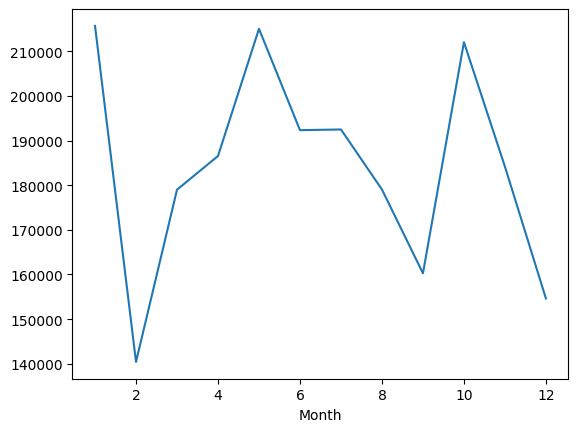

In [ ]:
Trend = df.groupby("Month")["Sales"].sum().plot(kind="line")

In [ ]:
# =========================
# FINAL DATA PREPARATION
# =========================

In [33]:
top_products = df.groupby("Product")["Profit"].sum().sort_values(ascending=False)
top_products = top_products.head(5)

In [34]:
weak_products = df.groupby("Product")["Profit"].sum().sort_values().head(5)

In [35]:
city_analysis = df.groupby("City").agg({
    "Sales": "sum",
    "Profit": "sum"
}).sort_values(by="Profit", ascending=False)

In [36]:
monthly_sales = df.groupby("Month")["Sales"].sum()

In [37]:
top_products_df = top_products.reset_index()
top_products_df.columns = ["Product", "Total_Profit"]

In [38]:
weak_products_df = weak_products.reset_index()
weak_products_df.columns = ["Product", "Total_Profit"]

In [39]:
city_analysis_df = city_analysis.reset_index()

In [40]:
monthly_sales_df = monthly_sales.reset_index()
monthly_sales_df.columns = ["Month", "Total_Sales"]

In [41]:
top_products_df = top_products_df.sort_values(by="Total_Profit", ascending=False)
weak_products_df = weak_products_df.sort_values(by="Total_Profit")

In [ ]:
with pd.ExcelWriter("Final_Report.xlsx") as writer:
    top_products_df.to_excel(writer, sheet_name="Top Products", index=False)
    weak_products_df.to_excel(writer, sheet_name="Weak Products", index=False)
    city_analysis_df.to_excel(writer, sheet_name="City Analysis", index=False)
    monthly_sales_df.to_excel(writer, sheet_name="Monthly Sales", index=False)